In [501]:
import pandas as pd
import numpy as np

In [502]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\end to end ML project\\notebook\\data\\stud.csv")

## Feature Engineering

### Feature Transformation

Finding the distribution of data 

In [503]:
numerical_cols = df.select_dtypes(exclude="object").columns
categorical_cols = df.select_dtypes(include="object").columns

In [504]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [505]:
for col in ['reading_score', 'writing_score']:
    lower = df[col].quantile(0.025)
    upper = df[col].quantile(0.975)

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Filtered Shape:", df.shape)

Filtered Shape: (909, 8)


In [506]:
X = df.drop(columns= ['math_score'])
y = df['math_score']

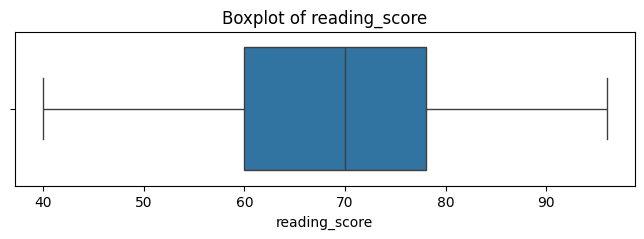

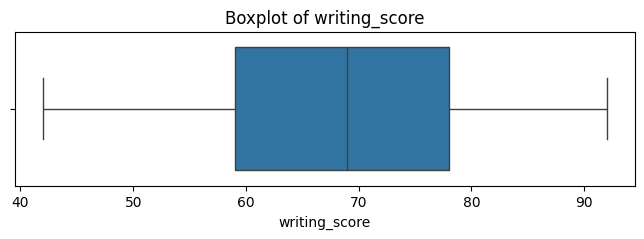

In [507]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = X.select_dtypes(include="number").columns

for col in numerical_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [508]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

In [509]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78


In [510]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [511]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

In [512]:
X_train.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
96,male,group B,some high school,standard,completed,-0.262278,-0.483035
12,female,group B,high school,standard,none,0.964724,0.398085
678,male,group D,associate's degree,free/reduced,none,0.473923,0.798594
278,female,group C,some high school,free/reduced,none,1.373725,0.958797
955,male,group E,associate's degree,standard,none,-0.998480,-0.483035


In [513]:
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
X_test.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
951,female,group D,some college,standard,completed,0.637524,1.199102
486,male,group D,some college,free/reduced,none,-1.816481,-0.963645
380,female,group B,associate's degree,standard,none,1.373725,1.199102
808,male,group C,high school,standard,none,0.473923,0.077678
863,female,group C,some college,standard,completed,0.146723,0.958797


In [514]:
df["gender"].value_counts()

gender
female    458
male      451
Name: count, dtype: int64

In [515]:
df["race_ethnicity"].value_counts()

race_ethnicity
group C    294
group D    238
group B    174
group E    121
group A     82
Name: count, dtype: int64

In [516]:
df["parental_level_of_education"].value_counts()

parental_level_of_education
some college          206
associate's degree    203
high school           183
some high school      162
bachelor's degree     104
master's degree        51
Name: count, dtype: int64

In [517]:
df["lunch"].value_counts()

lunch
standard        591
free/reduced    318
Name: count, dtype: int64

In [518]:
df['test_preparation_course'].value_counts()

test_preparation_course
none         585
completed    324
Name: count, dtype: int64

In [519]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

train_encoded = encoder.fit_transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])

train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

X_train = pd.concat([X_train, train_encoded_df], axis=1)
X_test = pd.concat([X_test, test_encoded_df], axis=1)

print(X_train.head())
print(X_train.shape)
print(X_test.shape)

     reading_score  writing_score  gender_female  gender_male  \
96       -0.262278      -0.483035            0.0          1.0   
12        0.964724       0.398085            1.0          0.0   
678       0.473923       0.798594            0.0          1.0   
278       1.373725       0.958797            1.0          0.0   
955      -0.998480      -0.483035            0.0          1.0   

     race_ethnicity_group A  race_ethnicity_group B  race_ethnicity_group C  \
96                      0.0                     1.0                     0.0   
12                      0.0                     1.0                     0.0   
678                     0.0                     0.0                     0.0   
278                     0.0                     0.0                     1.0   
955                     0.0                     0.0                     0.0   

     race_ethnicity_group D  race_ethnicity_group E  \
96                      0.0                     0.0   
12                      

In [520]:
X_train.shape

(727, 19)

In [521]:
X_test.shape

(182, 19)

In [522]:
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score

In [ ]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical(
        "regressor",
        [
            "LinearRegression",
            "ElasticNet",
            "Ridge",
            "SVR",
            "DecisionTreeRegressor",
            "RandomForest",
            "AdaBoost",
            "GradientBoosting",
            "XGBoost",
            "Voting",
            "Stacking"
        ]
    )

    if classifier_name == 'LinearRegression':
        # LR hyperparameters

        model = LinearRegression()

    elif classifier_name == 'ElasticNet':
        # ElasticNet hyperparameters
        alpha = trial.suggest_float('alpha', 0.001, 100)
        l1_ratio = trial.suggest_float('l1_ratio', 0, 1.0)
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=max_iter
        )

    elif classifier_name == 'Ridge':
        # Ridge hyperparameters
        max_iter = trial.suggest_int('max_iter', 100, 1000)
        alpha = trial.suggest_float('alpha', 0.001, 1000.0)

        model = Ridge(
            max_iter=max_iter,
            alpha = alpha,
        )

    elif classifier_name == 'SVR':
        # SVR hyperparameters
        C = trial.suggest_float('C', 0.001, 10.0)
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        model = SVR(
            C = C,
            max_iter=max_iter,
        )
        
    elif classifier_name == 'DecisionTreeRegressor':
        # DT hyperparameters
        criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "poisson"])
        splitter = trial.suggest_categorical("splitter", ["best", "random"])
        max_depth = trial.suggest_int("max_depth",2,1000)
        min_samples_split = trial.suggest_int("min_samples_split", 2,100)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2,100)

        model = DecisionTreeRegressor(
            criterion=criterion,
            splitter=splitter,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            max_leaf_nodes=max_leaf_nodes
        )
    
    elif classifier_name == "RandomForest":

        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        max_depth = trial.suggest_int("max_depth", 2, 50)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        )

    elif classifier_name == "AdaBoost":

        n_estimators = trial.suggest_int("n_estimators", 50, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 1.0, log=True)

        model = AdaBoostRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )

    elif classifier_name == "GradientBoosting":

        n_estimators = trial.suggest_int("n_estimators", 50, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.5, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)

        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            random_state=42
        )

    elif classifier_name == "XGBoost":

        n_estimators = trial.suggest_int("n_estimators", 100, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.3, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 10)
        subsample = trial.suggest_float("subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )

    elif classifier_name == "Voting":

        model = VotingRegressor(
            estimators=[
                ("lr", LinearRegression()),
                ("ridge", Ridge()),
                ("rf", RandomForestRegressor(random_state=42)),
            ]
        )

    elif classifier_name == "Stacking":

        estimators = [
            ("ridge", Ridge()),
            ("rf", RandomForestRegressor(random_state=42)),
            ("svr", make_pipeline(StandardScaler(), SVR()))
        ]

        model = StackingRegressor(
            estimators=estimators,
            final_estimator=LinearRegression(),
            n_jobs=-1
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return score

In [525]:
# Create a study and optimize it using CmaEsSampler
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=350)

[I 2026-07-22 08:29:43,695] A new study created in memory with name: no-name-0676fbee-f081-478b-9142-da1153eda4d1
[I 2026-07-22 08:29:43,742] Trial 0 finished with value: -0.0006182331866403009 and parameters: {'regressor': 'ElasticNet', 'alpha': 91.40178282550609, 'l1_ratio': 0.37139856177699815, 'max_iter': 546}. Best is trial 0 with value: -0.0006182331866403009.
[I 2026-07-22 08:29:46,611] Trial 1 finished with value: 0.7949765075452379 and parameters: {'regressor': 'RandomForest', 'n_estimators': 268, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.7949765075452379.
c:\Users\user\Desktop\end to end ML project\venv\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=560).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\user\Desktop\end to end ML project\venv\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated ea

In [526]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'regressor': 'LinearRegression'}
Best trial accuracy: 0.8277127940899042


In [527]:
best_params = study.best_trial.params

regressor = best_params.pop("regressor")

In [528]:
regressor

'LinearRegression'

In [532]:
lin_reg = LinearRegression(**best_params)

In [533]:
lin_reg.fit(X_train,y_train)
preds = lin_reg.predict(X_test)

In [534]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("RMSE: ", np.sqrt(mean_squared_error(y_test,preds)))
print("mae: ", mean_absolute_error(y_test, preds))
print("R2 score: ", r2_score(y_test, preds))

RMSE:  5.393290711953842
mae:  4.316454052408396
R2 score:  0.8318528741073216
